In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("fake_news_dataset.csv")

In [3]:
df.head()

,title,text,date,source,author,category,label
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake


In [4]:
df.head()

,title,text,date,source,author,category,label
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake


In [5]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (20000, 7)


### Cell 6 — Column Names

In [6]:
print("Columns in Dataset:")
print(df.columns)

Columns in Dataset:
Index(['title', 'text', 'date', 'source', 'author', 'category', 'label'], dtype='object')


### Cell 7 — Dataset Information
`df.info()`

This shows:

* datatype
* missing values
* memory usage

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     20000 non-null  object
 1   text      20000 non-null  object
 2   date      20000 non-null  object
 3   source    19000 non-null  object
 4   author    19000 non-null  object
 5   category  20000 non-null  object
 6   label     20000 non-null  object
dtypes: object(7)
memory usage: 1.1+ MB


### Cell 8 — Missing Values Check
`print("Missing Values:\n")`
`print(df.isnull().sum())`

**Expected:**
Likely missing in:

* author
* source

In [8]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

title          0
text           0
date           0
source      1000
author      1000
category       0
label          0
dtype: int64


### Cell 9 — Keep Only Useful Columns

We are intentionally dropping unnecessary columns.

`clean_df = df[[ "title", "text", "category", "label" ]]`

Check result:

`clean_df.head()`

In [9]:
clean_df = df[
    ["title", "text", "category", "label"]
]

clean_df.head()

,title,text,category,label
0,Foreign Democrat final.,more tax development both store agreement lawy...,Politics,real
1,To offer down resource great point.,probably guess western behind likely next inve...,Politics,fake
2,Himself church myself carry.,them identify forward present success risk sev...,Business,fake
3,You unit its should.,phone which item yard Republican safe where po...,Science,fake
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,Technology,fake


### Cell 10 — Check Missing Values Again
`print("Missing Values After Selecting Important Columns:\n")`
`print(clean_df.isnull().sum())`

In [10]:
print("Missing Values After Selecting Important Columns:\n")
print(clean_df.isnull().sum())

Missing Values After Selecting Important Columns:

title       0
text        0
category    0
label       0
dtype: int64


### Cell 11 — Remove Missing Values
`clean_df.dropna(inplace=True)`

Verify:

`print(clean_df.isnull().sum())`

In [11]:
clean_df.dropna(inplace=True)

print(clean_df.isnull().sum())

title       0
text        0
category    0
label       0
dtype: int64


/tmp/ipykernel_6863/3768894512.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df.dropna(inplace=True)


### Cell 12 — Check Duplicate Rows
`duplicate_count = clean_df.duplicated().sum()`

`print("Number of Duplicate Rows:", duplicate_count)`

In [12]:
duplicate_count = clean_df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


### Cell 13 — Remove Duplicates
`clean_df.drop_duplicates(inplace=True)`

`print("Duplicates Removed Successfully")`

Verify:

`print("Remaining Duplicates:", clean_df.duplicated().sum())`

In [13]:
clean_df.drop_duplicates(inplace=True)

print("Duplicates Removed Successfully")

print("Remaining Duplicates:",
      clean_df.duplicated().sum())

Duplicates Removed Successfully
Remaining Duplicates: 0


/tmp/ipykernel_6863/231979377.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df.drop_duplicates(inplace=True)


### Cell 14 — Check Label Distribution
`print(clean_df["label"].value_counts())`

This tells:

* fake count
* real count

In [14]:
print(clean_df["label"].value_counts())

label
fake    10056
real     9944
Name: count, dtype: int64


### Cell 15 — Visualize Label Distribution

`plt.figure(figsize=(6,4))`

`sns.countplot(`
`    x="label",`
`    data=clean_df`
`)`

`plt.title("Fake vs Real News Distribution")`
`plt.xlabel("Label")`
`plt.ylabel("Count")`

`plt.show()`

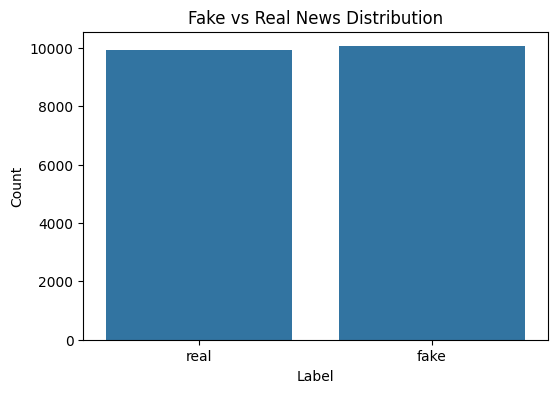

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="label",
    data=clean_df
)

plt.title("Fake vs Real News Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

### Cell 16 — Dataset Summary
`print("Final Cleaned Dataset Shape:", clean_df.shape)`

`clean_df.info()`

In [16]:
print("Final Cleaned Dataset Shape:",
      clean_df.shape)

clean_df.info()

Final Cleaned Dataset Shape: (20000, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     20000 non-null  object
 1   text      20000 non-null  object
 2   category  20000 non-null  object
 3   label     20000 non-null  object
dtypes: object(4)
memory usage: 625.1+ KB


### Cell 17 — Save Cleaned Dataset

Very important.

`clean_df.to_csv("cleaned_news_dataset.csv", index=False)`

`print("Cleaned dataset saved successfully!")`

In [17]:
clean_df.to_csv(
    "cleaned_news_dataset.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


### Cell 18 — Download Cleaned Dataset (Optional)

For local backup.

`from google.colab import files`

`files.download("cleaned_news_dataset.csv")`

In [18]:
from google.colab import files

files.download(
    "cleaned_news_dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>